# 04 — Machine-proxy behaviour injection

This notebook implements the semi-synthetic responsiveness analysis in Sections 2.6 and 3.5.

U-named calibration-window-0 target accounts receive progressively larger contiguous blocks of observed authentication events from fitting-window-0 dollar-suffix machine-proxy donors. The frozen K-means NHS is the primary endpoint.

The same hybrid account-windows are also evaluated with the frozen empirical-rank and custom-mixture scorers as a secondary sensitivity analysis.

No scorer is refitted and no test accounts are used.


## Reproducibility contract

This notebook is downstream of the frozen static pipeline. It must:

- reuse `static_features_v2/feat_final.parquet`;
- reuse the account split frozen in notebook 00;
- reuse the CORE5 representation frozen in 01b;
- reuse the fitted `kmeans_core5` scorer saved by 02b;
- use **fit-window-0 `$ machine proxy` accounts only as donors**;
- use **calibration-window-0 `U-named user proxy` accounts only as targets**;
- not materialise test feature rows;
- not refit preprocessing, centroids, score orientation or feature directions;
- recompute injected CORE5 values with the same feature definitions as notebook 01;
- use simulation repeats only to reduce Monte Carlo variability.

The inferential and bootstrap unit remains the **target account**.


## 0. Imports and configuration

In [1]:
print("=== 04 MACHINE-PROXY BEHAVIOUR INJECTION / FROZEN SCORERS ===")

from pathlib import Path
import hashlib
import json
import math
import pickle

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nhs_feature_utils as fu


AUTH_PATH = "/home/lanl/data/cyber1/auth.txt.gz"
AUTH_PARQUET = Path("auth_main.parquet")
FEATURE_PATH = Path("static_features_v2/feat_final.parquet")
FEATURE_META_PATH = Path("static_features_v2/feature_build_meta.json")
ACCOUNT_SPLIT_PATH = Path("account_split_static.json")
QUIET_HOURS_PATH = Path("quiet_hours.json")

REPRESENTATION_META_PATH = Path(
    "eda_outputs_01b_fit_features_core5/representation_meta.json"
)
MODEL_DIR = Path("static_model_comparison")
SCORERS_PATH = MODEL_DIR / "frozen_generic_scorers.pkl"
MODEL_META_PATH = MODEL_DIR / "model_comparison_meta.json"
MIXTURE_STATE_PATH = Path(
    "custom_mixture_development/custom_mixture_K6_state.json"
)

OUT = Path("machine_proxy_behaviour_injection")
OUT.mkdir(exist_ok=True)

TARGET_FEASIBILITY_PATH = OUT / "target_feasibility_window0.csv"
DONOR_ASSIGNMENTS_PATH = OUT / "machine_donor_assignments.csv"
INJECTION_MANIFEST_PATH = OUT / "injection_manifest.csv"
ORIGINAL_TARGETS_PATH = OUT / "target_original_core5_and_scores.csv"
SIM_ROWS_CSV_PATH = OUT / "simulated_additive_core5_and_scores.csv"
SIM_ROWS_PARQUET_PATH = OUT / "simulated_additive_core5_and_scores.parquet"
ACCOUNT_RESULTS_PATH = OUT / "account_level_responsiveness.csv"
PRIMARY_SUMMARY_PATH = OUT / "primary_responsiveness_summary.csv"
DOSE_RESPONSE_PATH = OUT / "account_dose_response.csv"
SANITY_PATH = OUT / "injection_sanity_checks.csv"
META_PATH = OUT / "behaviour_injection_meta.json"

TABLE14_PATH = OUT / "Table_14_kmeans_responsiveness.csv"
TABLE15_PATH = OUT / "Table_15_kmeans_feature_reversion.csv"
TABLE5_PATH = OUT / "Table_05_frozen_model_responsiveness.csv"

FIGURE5_PATH = OUT / "Figure_05_kmeans_injection_response.png"
FIGURE5_PDF_PATH = OUT / "Figure_05_kmeans_injection_response.pdf"
FIGURE6_PATH = OUT / "Figure_06_kmeans_feature_reversion.png"
FIGURE6_PDF_PATH = OUT / "Figure_06_kmeans_feature_reversion.pdf"

CORE5 = [
    "period_strength",
    "iat_cv",
    "log_volume",
    "log_fanout",
    "quiet_frac",
]

PRIMARY_METHOD = "kmeans_core5"
PRIMARY_WINDOW = 0
MACHINE_PROXY = "$ machine proxy"
USER_PROXY = "U-named user proxy"

WINDOW_DAYS = 14
WINDOW_S = WINDOW_DAYS * 86400

MIN_PERIOD = 50
BIN_S = 10
MAX_PERIOD_S = 6 * 3600

MIN_TARGET_EVENTS = 50
MIN_DONOR_EVENTS = 50

ALPHAS = (0.25, 0.50, 0.75)
N_REPLICATES = 5
DONOR_NEIGHBOURS = 50

N_BOOTSTRAP = 2000
SEED = 42

# Final analysis: leave as None.
# For a smoke test, temporarily set e.g. MAX_TARGETS = 50.
MAX_TARGETS = None

print("Frozen CORE5        :", CORE5)
print("Primary method      :", PRIMARY_METHOD)
print("Target proxy        :", USER_PROXY)
print("Machine donor proxy :", MACHINE_PROXY)
print("Injection strengths :", ALPHAS)
print("Replicates / target :", N_REPLICATES)
print("Output directory    :", OUT.resolve())


=== 04 MACHINE-PROXY BEHAVIOUR INJECTION / FROZEN SCORERS ===
Frozen CORE5        : ['period_strength', 'iat_cv', 'log_volume', 'log_fanout', 'quiet_frac']
Primary method      : kmeans_core5
Target proxy        : U-named user proxy
Machine donor proxy : $ machine proxy
Injection strengths : (0.25, 0.5, 0.75)
Replicates / target : 5
Output directory    : /home/pwps/ma/s/sz1325/msc_project/machine_proxy_behaviour_injection


## 1. Verify the frozen upstream state

In [2]:
def file_sha256(path):
    path = Path(path)
    if not path.exists():
        return None
    h = hashlib.sha256()
    with path.open("rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()


required_files = [
    AUTH_PARQUET,
    FEATURE_PATH,
    FEATURE_META_PATH,
    ACCOUNT_SPLIT_PATH,
    QUIET_HOURS_PATH,
    REPRESENTATION_META_PATH,
    SCORERS_PATH,
    MODEL_META_PATH,
]

for required in required_files:
    if not required.exists():
        raise FileNotFoundError(
            f"Missing required frozen input: {required}. "
            "Run the clean static notebooks first."
        )

feature_meta = json.loads(FEATURE_META_PATH.read_text())
representation_meta = json.loads(REPRESENTATION_META_PATH.read_text())
model_meta = json.loads(MODEL_META_PATH.read_text())
split_obj = json.loads(ACCOUNT_SPLIT_PATH.read_text())

expected_feature_hash = feature_meta.get("output_hashes", {}).get("feat_final")
actual_feature_hash = file_sha256(FEATURE_PATH)
if expected_feature_hash != actual_feature_hash:
    raise RuntimeError("Canonical feature-table hash has changed.")

expected_auth_hash = feature_meta.get("input_hashes", {}).get("auth_main_parquet")
actual_auth_hash = file_sha256(AUTH_PARQUET)
if expected_auth_hash != actual_auth_hash:
    raise RuntimeError(
        "auth_main.parquet does not match notebook-01 raw-event provenance."
    )

if representation_meta.get("representation_name") != "CORE5":
    raise RuntimeError("01b metadata does not declare CORE5.")
if representation_meta.get("core5_generic") != CORE5:
    raise RuntimeError("CORE5 mismatch between 01b and notebook 04.")
if representation_meta.get("feature_sha256") != actual_feature_hash:
    raise RuntimeError("01b representation metadata does not match the feature hash.")

if model_meta.get("core5") != CORE5:
    raise RuntimeError("CORE5 mismatch between 02b and notebook 04.")
if model_meta.get("feature_sha256") != actual_feature_hash:
    raise RuntimeError("02b metadata does not match the feature hash.")
if model_meta.get("test_evaluated") is not False:
    raise RuntimeError("02b metadata unexpectedly indicates test evaluation.")

if set(split_obj) != {"fit", "calibration", "test"}:
    raise RuntimeError(f"Unexpected split keys: {sorted(split_obj)}")

fit_a = set(map(str, split_obj["fit"]))
cal_a = set(map(str, split_obj["calibration"]))
test_a = set(map(str, split_obj["test"]))

assert fit_a.isdisjoint(cal_a)
assert fit_a.isdisjoint(test_a)
assert cal_a.isdisjoint(test_a)

with open(SCORERS_PATH, "rb") as f:
    frozen = pickle.load(f)

if frozen.get("core5") != CORE5:
    raise RuntimeError("Frozen 02b scorer-bundle CORE5 mismatch.")
if frozen.get("feature_sha256") != actual_feature_hash:
    raise RuntimeError("Frozen scorer bundle was fitted on a different feature table.")
if set(map(str, frozen["fit_accounts"])) != fit_a:
    raise RuntimeError("Frozen scorer fit-account identities mismatch.")
if set(map(str, frozen["calibration_accounts"])) != cal_a:
    raise RuntimeError("Frozen scorer calibration-account identities mismatch.")

scorers = frozen["scorers"]
if PRIMARY_METHOD not in scorers:
    raise RuntimeError(f"Frozen scorer bundle has no {PRIMARY_METHOD!r}.")
primary_scorer = scorers[PRIMARY_METHOD]

QUIET_HOURS = [int(x) for x in json.loads(QUIET_HOURS_PATH.read_text())]
if feature_meta.get("quiet_hours") != QUIET_HOURS:
    raise RuntimeError("quiet_hours.json differs from notebook-01 provenance.")

print("✓ Raw-event provenance verified.")
print("✓ Canonical CORE5 representation verified.")
print("✓ Frozen 02b K-means scorer loaded; no refitting.")
print("✓ Frozen account split verified.")
print("Test rows materialised: False")


✓ Raw-event provenance verified.
✓ Canonical CORE5 representation verified.
✓ Frozen 02b K-means scorer loaded; no refitting.
✓ Frozen account split verified.
Test rows materialised: False


## 2. Load fitting and calibration features only

Fitting window 0 supplies machine-proxy donor accounts and the frozen feature-reference distributions used only for explanation. Calibration window 0 supplies target accounts. Test identities remain unopened at the feature-row level.


In [3]:
fit_accounts_df = pd.DataFrame({"u": sorted(fit_a)})
cal_accounts_df = pd.DataFrame({"u": sorted(cal_a)})

con = duckdb.connect()
con.register("_fit_accounts_04", fit_accounts_df)
con.register("_cal_accounts_04", cal_accounts_df)

fit_df = con.execute(
    f"""
    SELECT f.*
    FROM read_parquet('{FEATURE_PATH.as_posix()}') AS f
    INNER JOIN _fit_accounts_04 AS a
        ON CAST(f.u AS VARCHAR) = a.u
    """
).df()

cal_df = con.execute(
    f"""
    SELECT f.*
    FROM read_parquet('{FEATURE_PATH.as_posix()}') AS f
    INNER JOIN _cal_accounts_04 AS a
        ON CAST(f.u AS VARCHAR) = a.u
    """
).df()

con.unregister("_fit_accounts_04")
con.unregister("_cal_accounts_04")
con.close()

fit_df["u"] = fit_df["u"].astype(str)
cal_df["u"] = cal_df["u"].astype(str)

for frame_name, frame in [("fit", fit_df), ("calibration", cal_df)]:
    missing = [
        c for c in ["u", "win", "volume", "fanout"] + CORE5
        if c not in frame.columns
    ]
    if missing:
        raise RuntimeError(f"{frame_name} rows missing columns: {missing}")
    if frame.duplicated(["u", "win"]).any():
        raise RuntimeError(f"Duplicate (u, win) rows in {frame_name} data.")

print(f"Fit rows/accounts        : {len(fit_df):,} / {fit_df.u.nunique():,}")
print(f"Calibration rows/accounts: {len(cal_df):,} / {cal_df.u.nunique():,}")
print(f"Test identities only     : {len(test_a):,}")
print("Test feature rows queried: 0")


Fit rows/accounts        : 62,310 / 17,734
Calibration rows/accounts: 15,722 / 4,433
Test identities only     : 7,391
Test feature rows queried: 0


## 3. Recreate the exact 01b proxy definitions

In [4]:
SYSTEM_REFERENCE_NAMES = [
    "SYSTEM",
    "LOCAL SERVICE",
    "NETWORK SERVICE",
]
ANONYMOUS_NAME = "ANONYMOUS LOGON"

ACCOUNT_TYPE_ORDER = [
    "U-named user proxy",
    "$ machine proxy",
    "named system",
    "anonymous logon",
    "other",
]

def account_type(u):
    s = str(u).upper()
    if "$@" in s or s.endswith("$"):
        return "$ machine proxy"
    if ANONYMOUS_NAME in s:
        return "anonymous logon"
    if any(name in s for name in SYSTEM_REFERENCE_NAMES):
        return "named system"
    if s.startswith("U"):
        return "U-named user proxy"
    return "other"


fit_w0 = fit_df.loc[fit_df["win"] == PRIMARY_WINDOW].copy()
cal_w0 = cal_df.loc[cal_df["win"] == PRIMARY_WINDOW].copy()

fit_w0["account_type"] = fit_w0["u"].map(account_type)
cal_w0["account_type"] = cal_w0["u"].map(account_type)

print("=== FIT WINDOW-0 PROXY COUNTS ===")
print(
    fit_w0["account_type"]
    .value_counts()
    .reindex(ACCOUNT_TYPE_ORDER)
    .dropna()
    .to_string()
)

print("\n=== CALIBRATION WINDOW-0 PROXY COUNTS ===")
print(
    cal_w0["account_type"]
    .value_counts()
    .reindex(ACCOUNT_TYPE_ORDER)
    .dropna()
    .to_string()
)


=== FIT WINDOW-0 PROXY COUNTS ===
account_type
U-named user proxy    5665.0
$ machine proxy       7118.0
named system          2404.0
anonymous logon        449.0

=== CALIBRATION WINDOW-0 PROXY COUNTS ===
account_type
U-named user proxy    1372.0
$ machine proxy       1847.0
named system           608.0
anonymous logon        113.0


## 4. Define target accounts and machine-proxy donor pool

Targets are calibration-window-0 `U-named user proxy` accounts with at least 50 original events and finite CORE5 values.

Donors are fit-window-0 `$ machine proxy` accounts. They are **not selected by NHS, periodicity or downstream score**.

For a target with original volume \(n_u\), the strongest intervention requires

$$
m_u^{\max}=\lfloor 0.75 n_u \rfloor
$$
additional donor events. A target is retained only if at least one fitting-set machine donor has enough observed events to supply this block without replacement.


In [5]:
max_alpha = max(ALPHAS)

target_pool = cal_w0.loc[
    (cal_w0["account_type"] == USER_PROXY)
    & (cal_w0["volume"] >= MIN_TARGET_EVENTS)
    & np.isfinite(cal_w0[CORE5]).all(axis=1)
].copy()

machine_donor_pool = fit_w0.loc[
    (fit_w0["account_type"] == MACHINE_PROXY)
    & (fit_w0["volume"] >= MIN_DONOR_EVENTS)
    & np.isfinite(fit_w0[CORE5]).all(axis=1)
].copy()

if target_pool.empty or machine_donor_pool.empty:
    raise RuntimeError("Target pool or machine-proxy donor pool is empty.")

target_pool["max_injected_events"] = np.floor(
    max_alpha * target_pool["volume"]
).astype(int)

max_machine_volume = int(machine_donor_pool["volume"].max())
target_pool["machine_donor_feasible"] = (
    target_pool["max_injected_events"] <= max_machine_volume
)

target_feasibility = target_pool[
    [
        "u",
        "volume",
        "log_volume",
        "max_injected_events",
        "machine_donor_feasible",
    ]
].copy()
target_feasibility.to_csv(TARGET_FEASIBILITY_PATH, index=False)

targets = (
    target_pool.loc[target_pool["machine_donor_feasible"]]
    .sort_values("u")
    .reset_index(drop=True)
)

if MAX_TARGETS is not None:
    if int(MAX_TARGETS) <= 0:
        raise ValueError("MAX_TARGETS must be None or a positive integer.")
    targets = targets.head(int(MAX_TARGETS)).copy()

if targets.empty:
    raise RuntimeError("No targets remain after machine-donor feasibility filtering.")

print(f"Initial eligible targets    : {len(target_pool):,}")
print(
    f"Machine-donor-feasible      : "
    f"{int(target_pool['machine_donor_feasible'].sum()):,}"
)
print(f"Targets used in this run    : {len(targets):,}")
print(f"$ machine-proxy donor pool  : {len(machine_donor_pool):,}")

if MAX_TARGETS is not None:
    print("WARNING: development run only; reset MAX_TARGETS=None for final results.")


Initial eligible targets    : 1,291
Machine-donor-feasible      : 1,291
Targets used in this run    : 1,291
$ machine-proxy donor pool  : 7,085


## 5. Deterministically assign volume-matched machine donors

For each target, feasible machine-proxy donors are ranked by absolute difference in `log_volume`. Each simulation replicate samples one donor from the nearest `DONOR_NEIGHBOURS` feasible donors.

Volume matching does **not** freeze the target's injected volume. Injection size is still fixed by \(\alpha n_u\). Matching only avoids systematically pairing a low-volume target with an extremely high-volume donor whose local event density may be unrepresentative.

The assigned donor is fixed across all \(\alpha\) values within a target–replicate pair.


In [6]:
def stable_seed(*parts, base_seed=SEED):
    payload = "|".join([str(base_seed)] + [str(x) for x in parts]).encode("utf-8")
    digest = hashlib.sha256(payload).digest()
    return int.from_bytes(digest[:8], "little", signed=False) % (2**32)


def assign_machine_donors(target_row):
    required = int(target_row["max_injected_events"])

    feasible = machine_donor_pool.loc[
    machine_donor_pool["volume"] >= required,
    ["u", "volume"] + CORE5,
    ].copy()

    if feasible.empty:
        raise RuntimeError(
            f"No machine donor can supply {required} events "
            f"for target {target_row['u']}."
        )

    feasible["abs_log_volume_gap"] = (
        feasible["log_volume"] - float(target_row["log_volume"])
    ).abs()

    local = (
        feasible.sort_values(["abs_log_volume_gap", "u"])
        .head(DONOR_NEIGHBOURS)
        .reset_index(drop=True)
    )

    rng = np.random.default_rng(
        stable_seed(target_row["u"], "machine_donor_assignment")
    )

    chosen_idx = rng.choice(
        len(local),
        size=N_REPLICATES,
        replace=(len(local) < N_REPLICATES),
    )

    rows = []
    for r, idx in enumerate(chosen_idx):
        donor = local.iloc[int(idx)]
        rows.append({
            "target_u": str(target_row["u"]),
            "replicate": int(r),
            "donor_u": str(donor["u"]),
            "target_volume": int(target_row["volume"]),
            "max_injected_events": required,
            "donor_volume": int(donor["volume"]),
            "donor_log_volume": float(donor["log_volume"]),
            "abs_log_volume_gap": float(donor["abs_log_volume_gap"]),
            "local_candidate_count": int(len(local)),
        })
    return rows


assignment_rows = []

for target_row in targets.itertuples(index=False):
    target_series = pd.Series(target_row._asdict())
    assignment_rows.extend(assign_machine_donors(target_series))

donor_assignments = pd.DataFrame(assignment_rows)

expected_assignment_rows = len(targets) * N_REPLICATES
if len(donor_assignments) != expected_assignment_rows:
    raise RuntimeError(
        f"Expected {expected_assignment_rows} donor assignments; "
        f"got {len(donor_assignments)}."
    )

donor_assignments.to_csv(DONOR_ASSIGNMENTS_PATH, index=False)

print(
    donor_assignments.agg(
        assignments=("donor_u", "size"),
        unique_donors=("donor_u", "nunique"),
        median_abs_log_volume_gap=("abs_log_volume_gap", "median"),
        max_abs_log_volume_gap=("abs_log_volume_gap", "max"),
    )
)


                           donor_u  abs_log_volume_gap
assignments                 6455.0                 NaN
unique_donors               2725.0                 NaN
median_abs_log_volume_gap      NaN            0.005577
max_abs_log_volume_gap         NaN            1.168175


## 6. Donor diagnostic

This is a descriptive check only. It does **not** filter or re-select donors.

The table compares the actual assigned `$ machine proxy` donors with the original target accounts on CORE5. It helps document what type of machine-proxy behaviour is being injected after the volume-matching step.


In [7]:
assigned_donor_ids = sorted(donor_assignments["donor_u"].astype(str).unique())

assigned_donor_features = (
    fit_w0.loc[fit_w0["u"].isin(assigned_donor_ids), ["u"] + CORE5]
    .drop_duplicates("u")
    .copy()
)

target_feature_snapshot = targets[["u"] + CORE5].copy()

diagnostic_rows = []
for feature in CORE5:
    diagnostic_rows.append({
        "feature": feature,
        "target_median": float(target_feature_snapshot[feature].median()),
        "assigned_machine_donor_median": float(
            assigned_donor_features[feature].median()
        ),
        "target_q25": float(target_feature_snapshot[feature].quantile(0.25)),
        "target_q75": float(target_feature_snapshot[feature].quantile(0.75)),
        "donor_q25": float(assigned_donor_features[feature].quantile(0.25)),
        "donor_q75": float(assigned_donor_features[feature].quantile(0.75)),
    })

donor_diagnostic = pd.DataFrame(diagnostic_rows)
print(donor_diagnostic.round(4).to_string(index=False))


        feature  target_median  assigned_machine_donor_median  target_q25  target_q75  donor_q25  donor_q75
period_strength        21.1804                        78.7415     12.7559     34.3103    28.2400   213.6195
         iat_cv         6.5291                         9.6859      2.5467     10.5189     1.5299    15.7575
     log_volume         3.1694                         3.3330      2.8865      3.3675     3.0406     3.5524
     log_fanout         1.1139                         1.1461      1.0414      1.1761     1.1139     1.1761
     quiet_frac         0.2230                         0.2385      0.0438      0.2895     0.0385     0.3026


## 7. Restore raw successful-`LogOn` events for selected targets and donors only

In [8]:
con_raw, MAX_T, N_WIN = fu.initialise_duckdb(
    auth_parquet=AUTH_PARQUET,
    auth_path=AUTH_PATH,
    window_days=WINDOW_DAYS,
    force_auth_rebuild=False,
)

selected_target_ids = pd.DataFrame(
    {"u": sorted(targets["u"].astype(str).unique())}
)
selected_donor_ids = pd.DataFrame(
    {"u": sorted(donor_assignments["donor_u"].astype(str).unique())}
)

con_raw.register("_targets_04", selected_target_ids)
target_events = con_raw.execute(
    f"""
    SELECT
        CAST(e.u AS VARCHAR) AS u,
        CAST(e.t AS BIGINT) AS t,
        CAST(e.dst_comp AS VARCHAR) AS dst_comp
    FROM e
    INNER JOIN _targets_04 AS x
        ON CAST(e.u AS VARCHAR) = x.u
    WHERE e.win = {PRIMARY_WINDOW}
    ORDER BY u, t, dst_comp
    """
).df()
con_raw.unregister("_targets_04")

con_raw.register("_donors_04", selected_donor_ids)
donor_events = con_raw.execute(
    f"""
    SELECT
        CAST(e.u AS VARCHAR) AS u,
        CAST(e.t AS BIGINT) AS t,
        CAST(e.dst_comp AS VARCHAR) AS dst_comp
    FROM e
    INNER JOIN _donors_04 AS x
        ON CAST(e.u AS VARCHAR) = x.u
    WHERE e.win = {PRIMARY_WINDOW}
    ORDER BY u, t, dst_comp
    """
).df()
con_raw.unregister("_donors_04")
con_raw.close()

target_event_map = {}
for u, g in target_events.groupby("u", sort=True):
    target_event_map[str(u)] = {
        "times": g["t"].to_numpy(dtype=np.int64, copy=True),
        "destinations": g["dst_comp"].astype(str).to_numpy(copy=True),
    }

donor_event_map = {}
for u, g in donor_events.groupby("u", sort=True):
    donor_event_map[str(u)] = {
        "times": g["t"].to_numpy(dtype=np.int64, copy=True),
        "destinations": g["dst_comp"].astype(str).to_numpy(copy=True),
    }

missing_targets = set(targets["u"].astype(str)) - set(target_event_map)
missing_donors = set(donor_assignments["donor_u"].astype(str)) - set(donor_event_map)

if missing_targets:
    raise RuntimeError(f"Targets missing raw events: {sorted(missing_targets)[:5]}")
if missing_donors:
    raise RuntimeError(f"Donors missing raw events: {sorted(missing_donors)[:5]}")

raw_target_counts = pd.Series(
    {u: len(v["times"]) for u, v in target_event_map.items()},
    name="raw_volume",
).rename_axis("u").reset_index()

count_check = targets[["u", "volume"]].merge(raw_target_counts, on="u")
if not np.array_equal(
    count_check["volume"].to_numpy(dtype=int),
    count_check["raw_volume"].to_numpy(dtype=int),
):
    raise RuntimeError("Raw target counts do not match canonical window-0 volume.")

window_start = PRIMARY_WINDOW * WINDOW_S
window_end = window_start + WINDOW_S

for donor_u, raw in donor_event_map.items():
    if (raw["times"] < window_start).any() or (raw["times"] >= window_end).any():
        raise RuntimeError(f"Donor {donor_u} has event time outside window 0.")

print(f"Raw target events loaded : {len(target_events):,}")
print(f"Target accounts loaded   : {len(target_event_map):,}")
print(f"Raw donor events loaded  : {len(donor_events):,}")
print(f"Unique donor accounts    : {len(donor_event_map):,}")
print("✓ Raw target volumes reproduce the canonical feature table.")


Using existing auth_main.parquet
Success events: 1,038,590,151
Complete 14-day windows: 4
Discarded tail: 172799 seconds
DuckDB views restored: a, e


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Raw target events loaded : 3,497,293
Target accounts loaded   : 1,291
Raw donor events loaded  : 14,002,146
Unique donor accounts    : 2,725
✓ Raw target volumes reproduce the canonical feature table.


## 8. Recompute CORE5 from an arbitrary hybrid event set

In [9]:
def core5_from_event_arrays(times, destinations):
    times = np.asarray(times, dtype=np.int64)
    destinations = np.asarray(destinations).astype(str)

    if len(times) != len(destinations):
        raise ValueError("times and destinations must have equal length.")
    if len(times) < 2:
        raise ValueError("At least two events are required.")

    order = np.argsort(times, kind="mergesort")
    ts = times[order]
    ds = destinations[order]

    volume = int(len(ts))
    fanout = int(pd.Series(ds).nunique(dropna=False))

    gaps = np.diff(ts).astype(float)
    mean_gap = float(gaps.mean()) if len(gaps) else np.nan
    iat_cv = (
        float(gaps.std(ddof=0) / mean_gap)
        if np.isfinite(mean_gap) and mean_gap > 0
        else np.nan
    )

    hours = ((ts % 86400) // 3600).astype(int)
    quiet_frac = float(np.isin(hours, QUIET_HOURS).mean())

    window_start = PRIMARY_WINDOW * WINDOW_S
    rel_times = ts - window_start

    if (rel_times < 0).any() or (rel_times >= WINDOW_S).any():
        raise RuntimeError("Hybrid event timestamp fell outside the 14-day window.")

    period_strength = fu.fisher_periodicity_strength(
        rel_times.tolist(),
        horizon=WINDOW_S,
        bin_s=BIN_S,
        max_period_s=MAX_PERIOD_S,
        min_period=MIN_PERIOD,
        robust=True,
    )

    return {
        "period_strength": (
            float(period_strength) if pd.notna(period_strength) else np.nan
        ),
        "iat_cv": iat_cv,
        "log_volume": float(np.log10(max(volume, 1))),
        "log_fanout": float(np.log10(max(fanout, 0) + 1)),
        "quiet_frac": quiet_frac,
        "volume": volume,
        "fanout": fanout,
    }


## 9. Validate event-level CORE5 recomputation against notebook 01

A deterministic sample of original, unmodified targets is reconstructed from raw events. The experiment stops if these values do not reproduce the canonical feature table.


In [10]:
VALIDATION_N = min(50, len(targets))
validation_targets = (
    targets[["u"]]
    .sample(n=VALIDATION_N, random_state=SEED)
    .sort_values("u")
)

validation_rows = []

for u in validation_targets["u"].astype(str):
    raw = target_event_map[u]
    now = core5_from_event_arrays(raw["times"], raw["destinations"])
    now["u"] = u
    validation_rows.append(now)

validation = pd.DataFrame(validation_rows).merge(
    targets[["u", "volume", "fanout"] + CORE5],
    on="u",
    how="left",
    suffixes=("_recomputed", "_canonical"),
)

for col in ["volume", "fanout"]:
    if not np.array_equal(
        validation[f"{col}_recomputed"].to_numpy(dtype=int),
        validation[f"{col}_canonical"].to_numpy(dtype=int),
    ):
        raise RuntimeError(f"Original-event recomputation mismatch in {col}.")

for col in CORE5:
    a = validation[f"{col}_recomputed"].to_numpy(dtype=float)
    b = validation[f"{col}_canonical"].to_numpy(dtype=float)
    if not np.allclose(a, b, rtol=1e-9, atol=1e-10, equal_nan=True):
        diff = np.nanmax(np.abs(a - b))
        raise RuntimeError(
            f"Original-event recomputation mismatch in {col}; max abs diff={diff}."
        )

print(
    f"✓ Event-level CORE5 reproduced notebook 01 for "
    f"{VALIDATION_N} deterministic targets."
)


✓ Event-level CORE5 reproduced notebook 01 for 50 deterministic targets.


## 10. Define the additive machine-behaviour injection

For each target–replicate pair:

1. the assigned `$ machine proxy` donor is fixed;
2. a random **contiguous block of \(m_u^{\max}\) observed donor events** is selected;
3. the block contains the donor's original timestamps and destination computers;
4. weaker \(\alpha\) values use centred nested sub-blocks of the same maximum block;
5. these donor events are appended to the complete original target event set.

No original target event is altered or removed.

Because target and donor accounts are taken from the same static window 0, donor timestamps can be used directly without time shifting. This preserves their observed time-of-day placement and local inter-arrival structure.


In [11]:
def centred_nested_slice(max_count, requested_count):
    if requested_count < 0 or requested_count > max_count:
        raise ValueError("requested_count must lie in [0, max_count].")
    start = (max_count - requested_count) // 2
    end = start + requested_count
    return slice(start, end)


assignment_lookup = {
    (str(row.target_u), int(row.replicate)): str(row.donor_u)
    for row in donor_assignments.itertuples(index=False)
}

sim_rows = []
manifest_rows = []

for target_idx, target_row in enumerate(targets.itertuples(index=False), start=1):
    target_u = str(target_row.u)
    raw_target = target_event_map[target_u]

    original_times = raw_target["times"]
    original_destinations = raw_target["destinations"]
    n_original = int(len(original_times))
    max_injected = int(math.floor(max_alpha * n_original))

    for r in range(N_REPLICATES):
        donor_u = assignment_lookup[(target_u, r)]
        raw_donor = donor_event_map[donor_u]
        donor_times = raw_donor["times"]
        donor_destinations = raw_donor["destinations"]

        if len(donor_times) < max_injected:
            raise RuntimeError(
                f"Donor {donor_u} has {len(donor_times)} events; "
                f"{max_injected} required for target {target_u}."
            )

        rng_block = np.random.default_rng(
            stable_seed(target_u, r, donor_u, "contiguous_donor_block")
        )

        max_start = len(donor_times) - max_injected
        block_start = int(rng_block.integers(0, max_start + 1))
        block_end = block_start + max_injected

        max_block_times = donor_times[block_start:block_end]
        max_block_destinations = donor_destinations[block_start:block_end]

        if len(max_block_times) != max_injected:
            raise RuntimeError("Maximum donor block has unexpected size.")

        for alpha in ALPHAS:
            m = int(math.floor(float(alpha) * n_original))
            sl = centred_nested_slice(max_injected, m)

            injected_times = max_block_times[sl]
            injected_destinations = max_block_destinations[sl]

            hybrid_times = np.concatenate([original_times, injected_times])
            hybrid_destinations = np.concatenate([
                original_destinations,
                injected_destinations,
            ])

            feats = core5_from_event_arrays(
                hybrid_times,
                hybrid_destinations,
            )

            expected_volume = n_original + m
            if feats["volume"] != expected_volume:
                raise RuntimeError(
                    f"Unexpected hybrid volume for {target_u}: "
                    f"{feats['volume']} != {expected_volume}"
                )

            original_fanout = int(
                pd.Series(original_destinations).nunique(dropna=False)
            )
            if feats["fanout"] < original_fanout:
                raise RuntimeError("Fan-out decreased after additive injection.")

            if m > 0:
                block_span_s = int(injected_times.max() - injected_times.min())
                injected_unique_dest = int(
                    pd.Series(injected_destinations).nunique(dropna=False)
                )
                inj_t_min = int(injected_times.min())
                inj_t_max = int(injected_times.max())
            else:
                block_span_s = 0
                injected_unique_dest = 0
                inj_t_min = np.nan
                inj_t_max = np.nan

            sim_rows.append({
                "u": target_u,
                "win": PRIMARY_WINDOW,
                "replicate": int(r),
                "alpha": float(alpha),
                "donor_u": donor_u,
                "n_original": n_original,
                "n_injected": int(m),
                "n_total": int(expected_volume),
                "injected_unique_destinations": injected_unique_dest,
                "injected_block_span_s": block_span_s,
                **feats,
            })

            manifest_rows.append({
                "u": target_u,
                "replicate": int(r),
                "alpha": float(alpha),
                "donor_u": donor_u,
                "target_original_volume": n_original,
                "max_injected_events": max_injected,
                "n_injected": int(m),
                "donor_total_volume": int(len(donor_times)),
                "max_block_start_index": block_start,
                "max_block_end_index_exclusive": block_end,
                "injected_time_min": inj_t_min,
                "injected_time_max": inj_t_max,
                "injected_block_span_s": block_span_s,
                "injected_unique_destinations": injected_unique_dest,
            })

    if target_idx % 100 == 0 or target_idx == len(targets):
        print(f"Processed targets: {target_idx:,}/{len(targets):,}")


sim = pd.DataFrame(sim_rows)
injection_manifest = pd.DataFrame(manifest_rows)

expected_rows = len(targets) * N_REPLICATES * len(ALPHAS)
if len(sim) != expected_rows:
    raise RuntimeError(
        f"Expected {expected_rows:,} simulation rows; got {len(sim):,}."
    )

if sim[CORE5].isna().any().any():
    missing = sim[CORE5].isna().sum()
    raise RuntimeError(
        "Injected CORE5 contains missing values:\n"
        + missing[missing > 0].to_string()
    )

injection_manifest.to_csv(INJECTION_MANIFEST_PATH, index=False)

print("Simulation rows:", sim.shape)
print(
    sim.groupby("alpha")
    .agg(
        rows=("u", "size"),
        accounts=("u", "nunique"),
        median_injected=("n_injected", "median"),
        median_total_volume=("volume", "median"),
    )
    .round(2)
    .to_string()
)


Processed targets: 100/1,291
Processed targets: 200/1,291
Processed targets: 300/1,291
Processed targets: 400/1,291
Processed targets: 500/1,291
Processed targets: 600/1,291
Processed targets: 700/1,291
Processed targets: 800/1,291
Processed targets: 900/1,291
Processed targets: 1,000/1,291
Processed targets: 1,100/1,291
Processed targets: 1,200/1,291
Processed targets: 1,291/1,291
Simulation rows: (19365, 17)
       rows  accounts  median_injected  median_total_volume
alpha                                                      
0.25   6455      1291            369.0               1846.0
0.50   6455      1291            738.0               2215.0
0.75   6455      1291           1107.0               2584.0


## 11. Apply the completely frozen K-means scorer

The scorer, preprocessing, fit medians, feature directions, standardisation and centroids all come from notebook 02b.

The **raw K-means score** is the primary endpoint. A fixed calibration-window-0 ECDF is also supplied only as a common 0–1 display scale; it is never recomputed after injection.


In [12]:
cal_w0_scores = np.asarray(primary_scorer.score(cal_w0), dtype=float)
if not np.isfinite(cal_w0_scores).all():
    raise RuntimeError("Calibration-window-0 scores contain non-finite values.")

cal_ref_sorted = np.sort(cal_w0_scores)

def fixed_calibration_percentile(scores):
    scores = np.asarray(scores, dtype=float)
    left = np.searchsorted(cal_ref_sorted, scores, side="left")
    right = np.searchsorted(cal_ref_sorted, scores, side="right")
    return (left + right) / (2.0 * len(cal_ref_sorted))


original_targets = targets[
    ["u", "win", "volume", "fanout"] + CORE5
].copy()

original_targets["score_kmeans_raw"] = np.asarray(
    primary_scorer.score(original_targets),
    dtype=float,
)
original_targets["score_kmeans_calref_pct"] = fixed_calibration_percentile(
    original_targets["score_kmeans_raw"]
)

sim["score_kmeans_raw"] = np.asarray(
    primary_scorer.score(sim),
    dtype=float,
)
sim["score_kmeans_calref_pct"] = fixed_calibration_percentile(
    sim["score_kmeans_raw"]
)

if not np.isfinite(sim["score_kmeans_raw"]).all():
    raise RuntimeError("Injected K-means scores contain non-finite values.")

original_targets.to_csv(ORIGINAL_TARGETS_PATH, index=False)
sim.to_csv(SIM_ROWS_CSV_PATH, index=False)

# Write Parquet through DuckDB, avoiding pandas/pyarrow dependence.
con_out = duckdb.connect()
con_out.register("_sim04", sim)
con_out.execute(
    f"COPY _sim04 TO '{SIM_ROWS_PARQUET_PATH.as_posix()}' "
    "(FORMAT PARQUET, COMPRESSION ZSTD)"
)
con_out.unregister("_sim04")
con_out.close()

print("✓ All injected rows scored with the frozen 02b K-means object.")
print("Saved:", SIM_ROWS_CSV_PATH)
print("Saved:", SIM_ROWS_PARQUET_PATH)


✓ All injected rows scored with the frozen 02b K-means object.
Saved: machine_proxy_behaviour_injection/simulated_additive_core5_and_scores.csv
Saved: machine_proxy_behaviour_injection/simulated_additive_core5_and_scores.parquet


## 12. Account-level paired responsiveness estimand

Simulation replicates are **not** treated as independent observations.

For each target and $\alpha$, first average the repeated injected scores:

$$
\overline{s}_u(\alpha)
=
\frac{1}{R}\sum_{r=1}^{R}s_{u,r}(\alpha).
$$

Then compute the paired change from that target's unmodified score:

$$
\Delta_u(\alpha)
=
\overline{s}_u(\alpha)-s_u(0).
$$


In [13]:
rep_mean = (
    sim.groupby(["u", "alpha"], as_index=False)
    .agg(
        mean_score_raw=("score_kmeans_raw", "mean"),
        mean_score_calref_pct=("score_kmeans_calref_pct", "mean"),
        mean_volume=("volume", "mean"),
        mean_fanout=("fanout", "mean"),
        n_replicates=("replicate", "nunique"),
    )
)

if not (rep_mean["n_replicates"] == N_REPLICATES).all():
    raise RuntimeError("Incomplete replicate set for at least one target/alpha.")

account_results = rep_mean.merge(
    original_targets[
        [
            "u",
            "volume",
            "fanout",
            "score_kmeans_raw",
            "score_kmeans_calref_pct",
        ]
    ].rename(columns={
        "volume": "volume_original",
        "fanout": "fanout_original",
        "score_kmeans_raw": "score_original_raw",
        "score_kmeans_calref_pct": "score_original_pct",
    }),
    on="u",
    how="left",
)

account_results["delta_score_raw"] = (
    account_results["mean_score_raw"] - account_results["score_original_raw"]
)
account_results["delta_score_pct"] = (
    account_results["mean_score_calref_pct"] - account_results["score_original_pct"]
)
account_results["delta_volume"] = (
    account_results["mean_volume"] - account_results["volume_original"]
)
account_results["delta_fanout"] = (
    account_results["mean_fanout"] - account_results["fanout_original"]
)

if len(account_results) != len(targets) * len(ALPHAS):
    raise RuntimeError("Unexpected number of account-level result rows.")

account_results.to_csv(ACCOUNT_RESULTS_PATH, index=False)
print(account_results.head().round(4).to_string(index=False))


          u  alpha  mean_score_raw  mean_score_calref_pct  mean_volume  mean_fanout  n_replicates  volume_original  fanout_original  score_original_raw  score_original_pct  delta_score_raw  delta_score_pct  delta_volume  delta_fanout
U10012@DOM1   0.25         -1.7203                 0.2048        335.0          9.8             5              268                8             -1.4589              0.2879          -0.2615          -0.0831          67.0           1.8
U10012@DOM1   0.50         -1.8158                 0.1645        402.0         11.6             5              268                8             -1.4589              0.2879          -0.3570          -0.1234         134.0           3.6
U10012@DOM1   0.75         -1.8323                 0.1603        469.0         12.4             5              268                8             -1.4589              0.2879          -0.3734          -0.1276         201.0           4.4
U10013@DOM1   0.25         -2.2078                 0.0394       

## 13. Account-level bootstrap summaries

In [14]:
def bootstrap_median_and_positive(values, n_boot=N_BOOTSTRAP, seed=SEED):
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return {
            "n_accounts": 0,
            "median": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
            "prop_positive": np.nan,
            "prop_positive_ci_low": np.nan,
            "prop_positive_ci_high": np.nan,
        }

    rng = np.random.default_rng(seed)
    boot_median = np.empty(n_boot)
    boot_prop = np.empty(n_boot)

    for b in range(n_boot):
        draw = x[rng.integers(0, len(x), size=len(x))]
        boot_median[b] = np.median(draw)
        boot_prop[b] = np.mean(draw > 0)

    return {
        "n_accounts": int(len(x)),
        "median": float(np.median(x)),
        "ci_low": float(np.quantile(boot_median, 0.025)),
        "ci_high": float(np.quantile(boot_median, 0.975)),
        "prop_positive": float(np.mean(x > 0)),
        "prop_positive_ci_low": float(np.quantile(boot_prop, 0.025)),
        "prop_positive_ci_high": float(np.quantile(boot_prop, 0.975)),
    }


summary_rows = []

for alpha in ALPHAS:
    sub = account_results.loc[account_results["alpha"] == alpha]

    for endpoint_name, col in {
        "raw_score_change": "delta_score_raw",
        "fixed_calibration_percentile_change": "delta_score_pct",
    }.items():
        stats = bootstrap_median_and_positive(
            sub[col].to_numpy(),
            seed=stable_seed(alpha, endpoint_name, "bootstrap"),
        )
        summary_rows.append({
            "alpha": float(alpha),
            "endpoint": endpoint_name,
            **stats,
        })

primary_summary = pd.DataFrame(summary_rows)
primary_summary.to_csv(PRIMARY_SUMMARY_PATH, index=False)

print("=== PRIMARY ADDITIVE MACHINE-PROXY RESPONSIVENESS RESULT ===")
print(
    primary_summary.loc[
        primary_summary["endpoint"] == "raw_score_change"
    ]
    .round(4)
    .to_string(index=False)
)


=== PRIMARY ADDITIVE MACHINE-PROXY RESPONSIVENESS RESULT ===
 alpha         endpoint  n_accounts  median  ci_low  ci_high  prop_positive  prop_positive_ci_low  prop_positive_ci_high
  0.25 raw_score_change        1291  0.0675  0.0576   0.0795         0.6677                0.6406                 0.6917
  0.50 raw_score_change        1291  0.1506  0.1313   0.1668         0.7026                0.6770                 0.7273
  0.75 raw_score_change        1291  0.2461  0.2220   0.2719         0.7428                0.7188                 0.7661


## 14. Dose-response summary

The dose-response analysis is anchored at the known baseline

$$
\Delta_u(0)=0.
$$

For each target, a linear slope is computed across
$\alpha\in\{0,0.25,0.50,0.75\}$.
The notebook also records whether the paired response is nondecreasing
across all four levels.


In [15]:
dose_rows = []

alpha_full = np.asarray((0.0,) + tuple(ALPHAS), dtype=float)
x_centered = alpha_full - alpha_full.mean()
x_denom = float(np.sum(x_centered**2))

for u, g in account_results.groupby("u", sort=True):
    g = g.sort_values("alpha")

    if not np.allclose(
        g["alpha"].to_numpy(dtype=float),
        np.asarray(ALPHAS, dtype=float),
    ):
        raise RuntimeError(f"Incomplete alpha sequence for target {u}.")

    injected_delta = g["delta_score_raw"].to_numpy(dtype=float)
    y = np.concatenate([[0.0], injected_delta])

    slope = float(np.sum(x_centered * (y - y.mean())) / x_denom)

    dose_rows.append({
        "u": str(u),
        "delta_alpha_000": 0.0,
        "delta_alpha_025": float(y[1]),
        "delta_alpha_050": float(y[2]),
        "delta_alpha_075": float(y[3]),
        "response_slope_per_alpha_unit": slope,
        "nondecreasing_from_baseline": bool(np.all(np.diff(y) >= -1e-12)),
    })

dose_response = pd.DataFrame(dose_rows)
dose_response.to_csv(DOSE_RESPONSE_PATH, index=False)

slope_stats = bootstrap_median_and_positive(
    dose_response["response_slope_per_alpha_unit"].to_numpy(),
    seed=stable_seed("dose_response_slope", "bootstrap"),
)

print(
    f"Median account slope: {slope_stats['median']:.4f} "
    f"(95% CI {slope_stats['ci_low']:.4f}, {slope_stats['ci_high']:.4f})"
)
print(
    f"Positive slope: {slope_stats['prop_positive']:.1%}; "
    f"nondecreasing from alpha=0 through 0.75: "
    f"{dose_response['nondecreasing_from_baseline'].mean():.1%}"
)


Median account slope: 0.3248 (95% CI 0.2938, 0.3556)
Positive slope: 74.1%; nondecreasing from alpha=0 through 0.75: 60.1%


## 15. Injection sanity checks

Unlike the timing-replacement experiment, volume and fan-out are **not expected to remain fixed**.

The required invariants are instead:

- no original events are removed;
- injected event count equals $\lfloor \alpha n_{\mathrm{original}} \rfloor$;
- total volume equals original volume plus injected volume;
- fan-out cannot decrease;
- all donor timestamps remain inside the same 14-day window;
- injected sets are nested within the same donor block by construction.


In [16]:
orig_check = original_targets[
    ["u", "volume", "fanout"]
].rename(columns={
    "volume": "volume_original",
    "fanout": "fanout_original",
})

san = sim[
    [
        "u",
        "replicate",
        "alpha",
        "n_original",
        "n_injected",
        "n_total",
        "volume",
        "fanout",
    ]
].merge(orig_check, on="u", how="left")

san["expected_injected"] = np.floor(
    san["alpha"] * san["volume_original"]
).astype(int)
san["expected_total"] = san["volume_original"] + san["expected_injected"]

sanity_checks = pd.DataFrame([
    {
        "check": "original_raw_count_matches_canonical",
        "n_failures": int(
            (san["n_original"] != san["volume_original"]).sum()
        ),
    },
    {
        "check": "injected_count_matches_alpha_definition",
        "n_failures": int(
            (san["n_injected"] != san["expected_injected"]).sum()
        ),
    },
    {
        "check": "recorded_total_matches_original_plus_injected",
        "n_failures": int(
            (san["n_total"] != san["expected_total"]).sum()
        ),
    },
    {
        "check": "recomputed_volume_matches_expected_total",
        "n_failures": int(
            (san["volume"] != san["expected_total"]).sum()
        ),
    },
    {
        "check": "fanout_never_decreases",
        "n_failures": int(
            (san["fanout"] < san["fanout_original"]).sum()
        ),
    },
])

manifest_time_failures = int(
    (
        (injection_manifest["injected_time_min"] < window_start)
        | (injection_manifest["injected_time_max"] >= window_end)
    ).fillna(False).sum()
)

sanity_checks = pd.concat(
    [
        sanity_checks,
        pd.DataFrame([{
            "check": "injected_times_within_window0",
            "n_failures": manifest_time_failures,
        }]),
    ],
    ignore_index=True,
)

if (sanity_checks["n_failures"] != 0).any():
    raise RuntimeError(
        "Injection sanity check failed:\n"
        + sanity_checks.to_string(index=False)
    )

sanity_checks.to_csv(SANITY_PATH, index=False)

print(sanity_checks.to_string(index=False))
print("✓ Additive injection invariants verified.")
print(
    "\nMedian feature changes by alpha:"
)
print(
    account_results.groupby("alpha")
    .agg(
        median_delta_volume=("delta_volume", "median"),
        median_delta_fanout=("delta_fanout", "median"),
    )
    .round(3)
    .to_string()
)


                                        check  n_failures
         original_raw_count_matches_canonical           0
      injected_count_matches_alpha_definition           0
recorded_total_matches_original_plus_injected           0
     recomputed_volume_matches_expected_total           0
                       fanout_never_decreases           0
                injected_times_within_window0           0
✓ Additive injection invariants verified.

Median feature changes by alpha:
       median_delta_volume  median_delta_fanout
alpha                                          
0.25                 369.0                  2.0
0.50                 738.0                  3.0
0.75                1107.0                  3.6


## 16. One-feature-reversion analysis for the frozen K-means score

The one-feature-reversion analysis examines how each injection-induced CORE5
change contributes to the frozen K-means score.

This diagnostic keeps the **frozen K-means scorer** and each fully injected
synthetic row unchanged except for one CORE5 feature at a time. For feature
$j$, its injected value is reverted to that target account's original value
while all other injected features remain unchanged:

$$
s^{(-j)}_{u,r}(\alpha)
=
s\!\left(
\mathbf{x}^{\mathrm{inject}}_{u,r}(\alpha)
\text{ with feature } j \text{ reverted to } x_{u,j}(0)
\right).
$$

The diagnostic effect is

$$
C_{u,r,j}(\alpha)
=
s^{\mathrm{full}}_{u,r}(\alpha)
-
s^{(-j)}_{u,r}(\alpha).
$$

A positive value means that the injection-induced change in that feature
pushes the frozen K-means score upward **conditional on the other four
injected features**.

These are not additive Shapley contributions: K-means distance geometry is
nonlinear and the feature effects can interact, so the five effects are not
expected to sum to the total score change.


=== ONE-FEATURE-REVERSION DIAGNOSTIC ===
        feature  alpha  median  ci_low  ci_high  prop_positive
period_strength   0.25 -0.0016 -0.0034   0.0000         0.4369
period_strength   0.50  0.0091  0.0072   0.0108         0.6189
period_strength   0.75  0.0272  0.0235   0.0303         0.7452
         iat_cv   0.25 -0.0081 -0.0090  -0.0072         0.2858
         iat_cv   0.50 -0.0116 -0.0138  -0.0098         0.3462
         iat_cv   0.75 -0.0134 -0.0164  -0.0109         0.3826
     log_volume   0.25  0.0937  0.0914   0.0960         0.9194
     log_volume   0.50  0.1701  0.1666   0.1741         0.9272
     log_volume   0.75  0.2310  0.2235   0.2368         0.9272
     log_fanout   0.25  0.0492  0.0473   0.0515         0.9202
     log_fanout   0.50  0.0658  0.0634   0.0697         0.9117
     log_fanout   0.75  0.0783  0.0748   0.0808         0.8815
     quiet_frac   0.25 -0.0065 -0.0126  -0.0030         0.3819
     quiet_frac   0.50 -0.0070 -0.0136  -0.0025         0.4113
     quiet_fra

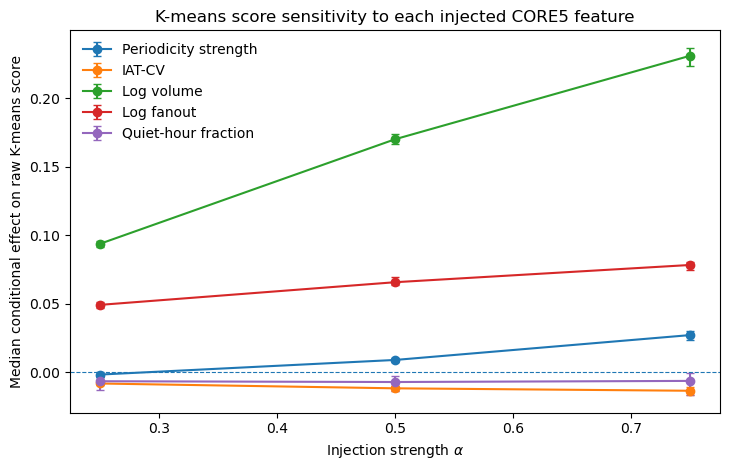

Saved: machine_proxy_behaviour_injection/Figure_06_kmeans_feature_reversion.png
Saved Figure 6: machine_proxy_behaviour_injection/Figure_06_kmeans_feature_reversion.png
Saved Table 15: machine_proxy_behaviour_injection/Table_15_kmeans_feature_reversion.csv


In [17]:

display_name = {
    "period_strength": "Periodicity strength",
    "iat_cv": "IAT-CV",
    "log_volume": "Log volume",
    "log_fanout": "Log fanout",
    "quiet_frac": "Quiet-hour fraction",
}

KMEANS_REVERSION_ROWS_PATH = OUT / "kmeans_one_feature_reversion_rows.csv"
KMEANS_REVERSION_ACCOUNT_PATH = OUT / "kmeans_one_feature_reversion_account_level.csv"
KMEANS_REVERSION_SUMMARY_PATH = OUT / "kmeans_one_feature_reversion_summary.csv"

original_core5_lookup = original_targets.set_index("u")[CORE5].copy()

reversion_rows = []

for feature in CORE5:
    counterfactual = sim.copy()

    original_vals = counterfactual["u"].map(
        original_core5_lookup[feature].to_dict()
    )

    if original_vals.isna().any():
        raise RuntimeError(
            f"Missing original target value while reverting {feature}."
        )

    counterfactual[feature] = original_vals.to_numpy(dtype=float)

    reverted_score = np.asarray(
        primary_scorer.score(counterfactual),
        dtype=float,
    )

    if not np.isfinite(reverted_score).all():
        raise RuntimeError(
            f"Non-finite frozen K-means score after reverting {feature}."
        )

    tmp = sim[
        ["u", "replicate", "alpha", "score_kmeans_raw"]
    ].copy()
    tmp["feature"] = feature
    tmp["score_reverted"] = reverted_score
    tmp["conditional_score_effect"] = (
        tmp["score_kmeans_raw"] - tmp["score_reverted"]
    )
    reversion_rows.append(tmp)

kmeans_reversion_rows = pd.concat(reversion_rows, ignore_index=True)
kmeans_reversion_rows.to_csv(KMEANS_REVERSION_ROWS_PATH, index=False)

kmeans_reversion_account = (
    kmeans_reversion_rows.groupby(
        ["u", "alpha", "feature"],
        as_index=False,
    )
    .agg(
        mean_conditional_score_effect=("conditional_score_effect", "mean"),
        n_replicates=("replicate", "nunique"),
    )
)

if not (kmeans_reversion_account["n_replicates"] == N_REPLICATES).all():
    raise RuntimeError("Incomplete replicate set in one-feature-reversion diagnostic.")

kmeans_reversion_account.to_csv(KMEANS_REVERSION_ACCOUNT_PATH, index=False)

reversion_summary_rows = []
for feature in CORE5:
    for alpha in ALPHAS:
        vals = kmeans_reversion_account.loc[
            (kmeans_reversion_account["feature"] == feature)
            & (kmeans_reversion_account["alpha"] == alpha),
            "mean_conditional_score_effect",
        ].to_numpy(dtype=float)

        stats = bootstrap_median_and_positive(
            vals,
            seed=stable_seed(
                "kmeans_reversion",
                feature,
                alpha,
                "bootstrap",
            ),
        )

        reversion_summary_rows.append({
            "feature": feature,
            "alpha": float(alpha),
            **stats,
        })

kmeans_reversion_summary = pd.DataFrame(reversion_summary_rows)
kmeans_reversion_summary.to_csv(KMEANS_REVERSION_SUMMARY_PATH, index=False)

print("=== ONE-FEATURE-REVERSION DIAGNOSTIC ===")
print(
    kmeans_reversion_summary[
        ["feature", "alpha", "median", "ci_low", "ci_high", "prop_positive"]
    ]
    .round(4)
    .to_string(index=False)
)

fig, ax = plt.subplots(figsize=(7.4, 4.8))
for feature, g in kmeans_reversion_summary.groupby("feature", sort=False):
    g = g.sort_values("alpha")
    ax.errorbar(
        g["alpha"],
        g["median"],
        yerr=[
            g["median"] - g["ci_low"],
            g["ci_high"] - g["median"],
        ],
        marker="o",
        capsize=3,
        label=display_name[feature],
    )

ax.axhline(0, linewidth=0.8, linestyle="--")
ax.set_xlabel(r"Injection strength $\alpha$")
ax.set_ylabel("Median conditional effect on raw K-means score")
ax.set_title("K-means score sensitivity to each injected CORE5 feature")
ax.legend(frameon=False)
fig.tight_layout()

figure6_png = FIGURE6_PATH
figure6_pdf = FIGURE6_PDF_PATH
fig.savefig(figure6_png, dpi=300, bbox_inches="tight")
fig.savefig(figure6_pdf, bbox_inches="tight")
plt.show()

print("Saved:", figure6_png)


table15 = (
    kmeans_reversion_summary.loc[
        kmeans_reversion_summary["alpha"] == max(ALPHAS),
        ["feature", "median", "prop_positive"],
    ]
    .rename(columns={
        "feature": "Feature",
        "median": "Median conditional effect",
        "prop_positive": "Proportion positive",
    })
    .sort_values("Median conditional effect", ascending=False)
)

table15.to_csv(TABLE15_PATH, index=False)

print("Saved Figure 6:", FIGURE6_PATH)
print("Saved Table 15:", TABLE15_PATH)


## 17. Sensitivity across frozen scoring constructions

The primary RQ2 result remains the selected frozen K-means NHS. This section
does **not** reopen model selection.

Instead, the exact same original and injected account-windows are scored by
the three multivariate constructions already retained upstream:

1. empirical-rank CORE5 baseline;
2. K-means CORE5;
3. custom probabilistic mixture CORE5 with frozen $K=6$.

The baseline and K-means scorers are loaded from the same frozen 02b bundle.
The custom mixture reuses the frozen parameters and machine-side component
allocation.

For the custom mixture, the unsquashed log-likelihood ratio (LLR) is used,
matching notebook 03's substantive comparison scale and avoiding posterior
saturation.

Raw score units differ across models and are therefore **not compared
directly**. For each model, a fixed empirical CDF is estimated once from the
original calibration-window-0 scores:

$$
R_m(s)=\widehat{F}_{m,\mathrm{cal},0}(s).
$$

Responsiveness is compared on this common within-model reference scale:

$$
\Delta R_{m,u}(\alpha)
=
\overline{R}_{m,u}(\alpha)-R_{m,u}(0).
$$

A larger positive value means a larger movement toward that model's
high-score tail relative to its own frozen calibration reference.


In [18]:
import nhs_mixture as mix

MIXTURE_SOURCE_PATH = Path("nhs_mixture.py")

MODEL_RESP_ACCOUNT_PATH = OUT / "model_responsiveness_account_level.csv"
MODEL_RESP_SUMMARY_PATH = OUT / "model_responsiveness_summary.csv"
MODEL_DOSE_PATH = OUT / "model_responsiveness_dose_response.csv"

for required in [MIXTURE_STATE_PATH, MIXTURE_SOURCE_PATH]:
    if not required.exists():
        raise FileNotFoundError(f"Missing frozen mixture input: {required}")

mixture_state = json.loads(MIXTURE_STATE_PATH.read_text())

if mixture_state.get("feature_sha256") != actual_feature_hash:
    raise RuntimeError("Frozen custom-mixture feature hash mismatch.")
if mixture_state.get("K") != 6:
    raise RuntimeError("Expected frozen custom mixture K=6.")
state_version = mixture_state.get(
    "mixture_model_version",
    mix.MIXTURE_MODEL_VERSION,
)
if state_version != mix.MIXTURE_MODEL_VERSION:
    raise RuntimeError(
        "Frozen custom-mixture state uses a different model implementation."
    )

if "empirical_rank" not in scorers:
    raise RuntimeError("Frozen scorer bundle has no empirical_rank scorer.")

baseline_scorer = scorers["empirical_rank"]
mixture_params = mixture_state["params"]
mixture_machine_comps = mixture_state["machine_comps"]

# Fixed calibration-window-0 score references.
cal_model_scores = {
    "Empirical-rank baseline": np.asarray(
        baseline_scorer.score(cal_w0),
        dtype=float,
    ),
    "K-means": np.asarray(
        primary_scorer.score(cal_w0),
        dtype=float,
    ),
    "Custom mixture": np.asarray(
        mix.score_mixture_k(
            cal_w0,
            mixture_params,
            mixture_machine_comps,
            return_llr=True,
        ),
        dtype=float,
    ),
}

for model_name, values in cal_model_scores.items():
    if not np.isfinite(values).all():
        raise RuntimeError(
            f"Calibration reference contains non-finite scores for {model_name}."
        )


def fixed_reference_percentile(scores, reference_scores):
    scores = np.asarray(scores, dtype=float)
    ref = np.sort(np.asarray(reference_scores, dtype=float))

    if not np.isfinite(scores).all() or not np.isfinite(ref).all():
        raise ValueError("Percentile mapping requires finite values.")

    left = np.searchsorted(ref, scores, side="left")
    right = np.searchsorted(ref, scores, side="right")
    return (left + right) / (2.0 * len(ref))


# Raw scores for original targets.
original_model_scores = {
    "Empirical-rank baseline": np.asarray(
        baseline_scorer.score(original_targets),
        dtype=float,
    ),
    "K-means": original_targets["score_kmeans_raw"].to_numpy(dtype=float),
    "Custom mixture": np.asarray(
        mix.score_mixture_k(
            original_targets,
            mixture_params,
            mixture_machine_comps,
            return_llr=True,
        ),
        dtype=float,
    ),
}

# Raw scores for the exact same injected rows.
sim_model_scores = {
    "Empirical-rank baseline": np.asarray(
        baseline_scorer.score(sim),
        dtype=float,
    ),
    "K-means": sim["score_kmeans_raw"].to_numpy(dtype=float),
    "Custom mixture": np.asarray(
        mix.score_mixture_k(
            sim,
            mixture_params,
            mixture_machine_comps,
            return_llr=True,
        ),
        dtype=float,
    ),
}

model_account_rows = []

for model_name in [
    "Empirical-rank baseline",
    "K-means",
    "Custom mixture",
]:
    ref_scores = cal_model_scores[model_name]
    orig_raw = original_model_scores[model_name]
    inj_raw = sim_model_scores[model_name]

    if not np.isfinite(orig_raw).all():
        raise RuntimeError(f"Non-finite original score for {model_name}.")
    if not np.isfinite(inj_raw).all():
        raise RuntimeError(f"Non-finite injected score for {model_name}.")

    orig_pct = fixed_reference_percentile(orig_raw, ref_scores)
    inj_pct = fixed_reference_percentile(inj_raw, ref_scores)

    orig_tmp = pd.DataFrame({
        "u": original_targets["u"].astype(str).to_numpy(),
        "original_raw": orig_raw,
        "original_ref_pct": orig_pct,
    })

    sim_tmp = sim[["u", "replicate", "alpha"]].copy()
    sim_tmp["injected_raw"] = inj_raw
    sim_tmp["injected_ref_pct"] = inj_pct

    rep_mean_tmp = (
        sim_tmp.groupby(["u", "alpha"], as_index=False)
        .agg(
            mean_injected_raw=("injected_raw", "mean"),
            mean_injected_ref_pct=("injected_ref_pct", "mean"),
            n_replicates=("replicate", "nunique"),
        )
        .merge(orig_tmp, on="u", how="left")
    )

    rep_mean_tmp["model"] = model_name
    rep_mean_tmp["delta_raw"] = (
        rep_mean_tmp["mean_injected_raw"] - rep_mean_tmp["original_raw"]
    )
    rep_mean_tmp["delta_ref_pct"] = (
        rep_mean_tmp["mean_injected_ref_pct"]
        - rep_mean_tmp["original_ref_pct"]
    )

    model_account_rows.append(rep_mean_tmp)

model_responsiveness_account = pd.concat(
    model_account_rows,
    ignore_index=True,
)

if not (
    model_responsiveness_account["n_replicates"] == N_REPLICATES
).all():
    raise RuntimeError("Incomplete model-comparison replicate set.")

# K-means percentile result should reproduce the already-computed primary scale.
k_new = (
    model_responsiveness_account.loc[
        model_responsiveness_account["model"] == "K-means",
        ["u", "alpha", "delta_ref_pct"],
    ]
    .sort_values(["u", "alpha"])
    .reset_index(drop=True)
)

k_old = (
    account_results[
        ["u", "alpha", "delta_score_pct"]
    ]
    .sort_values(["u", "alpha"])
    .reset_index(drop=True)
)

if not (
    k_new[["u", "alpha"]].equals(k_old[["u", "alpha"]])
    and np.allclose(
        k_new["delta_ref_pct"].to_numpy(dtype=float),
        k_old["delta_score_pct"].to_numpy(dtype=float),
        atol=1e-12,
        rtol=0,
    )
):
    raise RuntimeError(
        "K-means fixed-reference percentile does not reproduce "
        "the primary 04 percentile calculation."
    )

model_responsiveness_account.to_csv(
    MODEL_RESP_ACCOUNT_PATH,
    index=False,
)

model_summary_rows = []
for model_name in [
    "Empirical-rank baseline",
    "K-means",
    "Custom mixture",
]:
    for alpha in ALPHAS:
        vals = model_responsiveness_account.loc[
            (model_responsiveness_account["model"] == model_name)
            & (model_responsiveness_account["alpha"] == alpha),
            "delta_ref_pct",
        ].to_numpy(dtype=float)

        stats = bootstrap_median_and_positive(
            vals,
            seed=stable_seed(
                "model_responsiveness",
                model_name,
                alpha,
                "bootstrap",
            ),
        )

        model_summary_rows.append({
            "model": model_name,
            "alpha": float(alpha),
            **stats,
        })

model_responsiveness_summary = pd.DataFrame(model_summary_rows)
model_responsiveness_summary.to_csv(
    MODEL_RESP_SUMMARY_PATH,
    index=False,
)

# Account-level dose response on the common within-model percentile scale.
model_dose_rows = []

alpha_full = np.asarray((0.0,) + tuple(ALPHAS), dtype=float)
x_centered = alpha_full - alpha_full.mean()
x_denom = float(np.sum(x_centered**2))

for model_name, df_model in model_responsiveness_account.groupby(
    "model",
    sort=False,
):
    account_slopes = []
    monotonic_flags = []

    for u, g in df_model.groupby("u", sort=True):
        g = g.sort_values("alpha")

        if not np.allclose(
            g["alpha"].to_numpy(dtype=float),
            np.asarray(ALPHAS, dtype=float),
        ):
            raise RuntimeError(
                f"Incomplete alpha sequence for {model_name}, {u}."
            )

        y = np.concatenate([
            [0.0],
            g["delta_ref_pct"].to_numpy(dtype=float),
        ])

        slope = float(
            np.sum(x_centered * (y - y.mean())) / x_denom
        )
        account_slopes.append(slope)
        monotonic_flags.append(
            bool(np.all(np.diff(y) >= -1e-12))
        )

    slope_stats_model = bootstrap_median_and_positive(
        np.asarray(account_slopes, dtype=float),
        seed=stable_seed(
            "model_dose",
            model_name,
            "bootstrap",
        ),
    )

    alpha75 = model_responsiveness_summary.loc[
        (model_responsiveness_summary["model"] == model_name)
        & (model_responsiveness_summary["alpha"] == max(ALPHAS))
    ].iloc[0]

    model_dose_rows.append({
        "model": model_name,
        "n_accounts": int(len(account_slopes)),
        "median_slope": slope_stats_model["median"],
        "slope_ci_low": slope_stats_model["ci_low"],
        "slope_ci_high": slope_stats_model["ci_high"],
        "prop_positive_slope": slope_stats_model["prop_positive"],
        "prop_nondecreasing_from_baseline": float(
            np.mean(monotonic_flags)
        ),
        "alpha075_median_delta_ref_pct": float(alpha75["median"]),
        "alpha075_prop_positive": float(alpha75["prop_positive"]),
    })

model_dose_response = pd.DataFrame(model_dose_rows)
model_dose_response.to_csv(MODEL_DOSE_PATH, index=False)

print("=== SECONDARY FROZEN-MODEL RESPONSIVENESS COMPARISON ===")
print(
    model_responsiveness_summary[
        ["model", "alpha", "median", "ci_low", "ci_high", "prop_positive"]
    ]
    .round(4)
    .to_string(index=False)
)

print("\n=== MODEL-LEVEL DOSE-RESPONSE SUMMARY ===")
print(model_dose_response.round(4).to_string(index=False))
print("\nMixture comparison score: frozen K=6 log-likelihood ratio (LLR).")
print("No scorer was refitted; model selection remains closed.")


table5 = (
    model_responsiveness_summary.pivot(
        index="model",
        columns="alpha",
        values="median",
    )
    .reset_index()
    .rename(columns={
        "model": "Scoring method",
        0.25: "alpha_0.25",
        0.50: "alpha_0.50",
        0.75: "alpha_0.75",
    })
)

table5.to_csv(TABLE5_PATH, index=False)
print("Saved Table 5:", TABLE5_PATH)


=== SECONDARY FROZEN-MODEL RESPONSIVENESS COMPARISON ===
                  model  alpha  median  ci_low  ci_high  prop_positive
Empirical-rank baseline   0.25  0.0490  0.0464   0.0525         0.8722
Empirical-rank baseline   0.50  0.0800  0.0751   0.0859         0.8931
Empirical-rank baseline   0.75  0.1096  0.1028   0.1160         0.9171
                K-means   0.25  0.0147  0.0124   0.0169         0.6631
                K-means   0.50  0.0306  0.0259   0.0361         0.6971
                K-means   0.75  0.0516  0.0442   0.0581         0.7266
         Custom mixture   0.25  0.0078  0.0062   0.0098         0.6290
         Custom mixture   0.50  0.0139  0.0107   0.0170         0.6305
         Custom mixture   0.75  0.0178  0.0128   0.0230         0.6313

=== MODEL-LEVEL DOSE-RESPONSE SUMMARY ===
                  model  n_accounts  median_slope  slope_ci_low  slope_ci_high  prop_positive_slope  prop_nondecreasing_from_baseline  alpha075_median_delta_ref_pct  alpha075_prop_positive
E

In [19]:
print("=== Frozen-model responsiveness — dissertation Table 5 ===")
display(table5.round(4))


=== Frozen-model responsiveness — dissertation Table 5 ===


alpha,Scoring method,alpha_0.25,alpha_0.50,alpha_0.75
0,Custom mixture,0.0078,0.0139,0.0178
1,Empirical-rank baseline,0.0490,0.0800,0.1096
2,K-means,0.0147,0.0306,0.0516


## 18. Dissertation Figure 5 and Supplementary Table 14


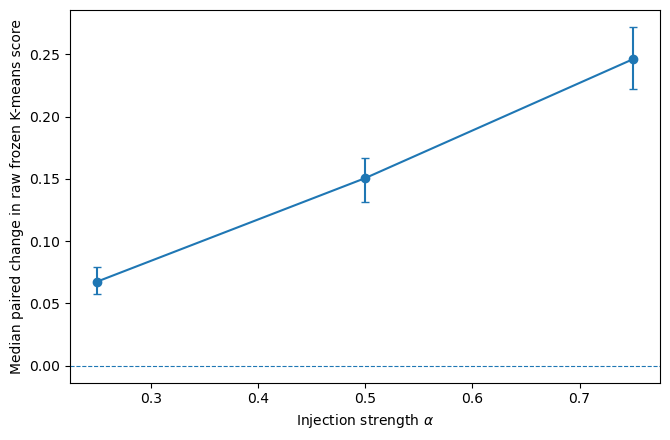

Saved Figure 5: machine_proxy_behaviour_injection/Figure_05_kmeans_injection_response.png
Saved Table 14: machine_proxy_behaviour_injection/Table_14_kmeans_responsiveness.csv


In [20]:
primary_plot = primary_summary.loc[
    primary_summary["endpoint"] == "raw_score_change"
].sort_values("alpha")

fig, ax = plt.subplots(figsize=(6.8, 4.5))
ax.errorbar(
    primary_plot["alpha"],
    primary_plot["median"],
    yerr=[
        primary_plot["median"] - primary_plot["ci_low"],
        primary_plot["ci_high"] - primary_plot["median"],
    ],
    marker="o",
    capsize=3,
)
ax.axhline(0, linewidth=0.8, linestyle="--")
ax.set_xlabel(r"Injection strength $\alpha$")
ax.set_ylabel("Median paired change in raw frozen K-means score")
fig.tight_layout()

fig.savefig(FIGURE5_PATH, dpi=300, bbox_inches="tight")
fig.savefig(FIGURE5_PDF_PATH, bbox_inches="tight")
plt.show()

table14 = primary_plot[
    [
        "alpha",
        "median",
        "ci_low",
        "ci_high",
        "prop_positive",
    ]
].rename(columns={
    "alpha": "Injection strength alpha",
    "median": "Median delta_sKM",
    "ci_low": "CI low",
    "ci_high": "CI high",
    "prop_positive": "Pr(delta_sKM > 0)",
})

table14.to_csv(TABLE14_PATH, index=False)

print("Saved Figure 5:", FIGURE5_PATH)
print("Saved Table 14:", TABLE14_PATH)

## 19. Save provenance and final checkpoint


In [21]:
output_paths = [
    TARGET_FEASIBILITY_PATH,
    DONOR_ASSIGNMENTS_PATH,
    INJECTION_MANIFEST_PATH,
    ORIGINAL_TARGETS_PATH,
    SIM_ROWS_CSV_PATH,
    SIM_ROWS_PARQUET_PATH,
    ACCOUNT_RESULTS_PATH,
    PRIMARY_SUMMARY_PATH,
    KMEANS_REVERSION_ROWS_PATH,
    KMEANS_REVERSION_ACCOUNT_PATH,
    KMEANS_REVERSION_SUMMARY_PATH,
    MODEL_RESP_ACCOUNT_PATH,
    MODEL_RESP_SUMMARY_PATH,
    MODEL_DOSE_PATH,
    TABLE14_PATH,
    TABLE15_PATH,
    TABLE5_PATH,
    FIGURE5_PATH,
    FIGURE5_PDF_PATH,
    FIGURE6_PATH,
    FIGURE6_PDF_PATH,
]

meta = {
    "pipeline_stage": "04_machine_proxy_behaviour_injection",
    "target_partition": "calibration",
    "target_window": int(PRIMARY_WINDOW),
    "target_proxy": USER_PROXY,
    "donor_partition": "fit",
    "donor_proxy": MACHINE_PROXY,
    "alphas": [float(x) for x in ALPHAS],
    "n_replicates": int(N_REPLICATES),
    "donor_neighbours": int(DONOR_NEIGHBOURS),
    "n_bootstrap": int(N_BOOTSTRAP),
    "core5": CORE5,
    "primary_scorer": PRIMARY_METHOD,
    "models_refitted": False,
    "test_evaluated": False,
    "n_targets": int(len(targets)),
    "outputs": {
        str(path): file_sha256(path)
        for path in output_paths
        if Path(path).exists()
    },
}

META_PATH.write_text(json.dumps(meta, indent=2))

print("========== 04 RESPONSIVENESS CHECKPOINT ==========")
print(f"Targets used    : {len(targets):,}")
print(f"Donor pool      : {len(machine_donor_pool):,}")
print(f"Alphas          : {ALPHAS}")
print(f"Replicates      : {N_REPLICATES}")
print("Models refitted : False")
print("Test evaluated  : False")

print("\nPrimary K-means response:")
display(table14.round(4))

print("\nFeature-reversion diagnostic at alpha=0.75:")
display(table15.round(4))

print("\nFrozen-model sensitivity:")
display(table5.round(4))

print("\nOutputs:", OUT.resolve())

========== 04 RESPONSIVENESS CHECKPOINT ==========
Targets used    : 1,291
Donor pool      : 7,085
Alphas          : (0.25, 0.5, 0.75)
Replicates      : 5
Models refitted : False
Test evaluated  : False

Primary K-means response:


,Injection strength alpha,Median delta_sKM,CI low,CI high,Pr(delta_sKM > 0)
0,0.25,0.0675,0.0576,0.0795,0.6677
2,0.50,0.1506,0.1313,0.1668,0.7026
4,0.75,0.2461,0.2220,0.2719,0.7428



Feature-reversion diagnostic at alpha=0.75:


,Feature,Median conditional effect,Proportion positive
8,log_volume,0.2310,0.9272
11,log_fanout,0.0783,0.8815
2,period_strength,0.0272,0.7452
14,quiet_frac,-0.0062,0.4361
5,iat_cv,-0.0134,0.3826



Frozen-model sensitivity:


alpha,Scoring method,alpha_0.25,alpha_0.50,alpha_0.75
0,Custom mixture,0.0078,0.0139,0.0178
1,Empirical-rank baseline,0.0490,0.0800,0.1096
2,K-means,0.0147,0.0306,0.0516



Outputs: /home/pwps/ma/s/sz1325/msc_project/machine_proxy_behaviour_injection
